In [5]:
using JuMP
using Gurobi
using Random
using Dualization
using Plots
using DataFrames
using CSV
import XLSX
import JSON

current_directory = @__DIR__
functions_directory = joinpath(current_directory, "functions")
data_dir = joinpath(current_directory, "data")
results_dir = joinpath(current_directory, "results")

# Include all the function files
# include(joinpath(functions_directory, "create_check_params.jl"))
# include(joinpath(functions_directory, "deterministic_equivalent.jl"))
# include(joinpath(functions_directory, "generate_cuts_from_dual.jl"))
include(joinpath(functions_directory, "load_model_starting_points.jl"))
# include(joinpath(functions_directory, "load_model_starting_points_OLD.jl"))
include(joinpath(functions_directory, "initialize_parameters.jl"))
include(joinpath(functions_directory, "process_scenario_data_n_selected_with_MVP.jl"))
include(joinpath(functions_directory, "process_scenario_data_n_selected.jl"))
# include(joinpath(functions_directory, "save_L_shaped_results.jl"))
include(joinpath(functions_directory, "select_random_scenarios.jl"))
include(joinpath(functions_directory, "create_vaccine_data.jl"))
# include(joinpath(functions_directory, "sub_problem.jl"))
# include(joinpath(functions_directory, "master_problem.jl"))
include(joinpath(functions_directory, "create_vaccine_data_MMR_only.jl"))

create_vaccine_data_MMR_only (generic function with 1 method)

In [7]:
A, V, A_v, P, P_v, V_a, V_p, P_a, A_p, capacity_category, vaccine_category, antigen_category = create_vaccine_data_MMR_only()

(["Measles", "Mumps", "Rubella"], ["M", "MR", "MMR"], Dict("MMR" => ["Measles", "Mumps", "Rubella"], "MR" => ["Measles", "Rubella"], "M" => ["Measles"]), ["Biological_E", "GSK", "PT_Bio", "Serum_Institute"], Dict("MMR" => ["Serum_Institute", "GSK"], "MR" => ["Serum_Institute", "Biological_E"], "M" => ["Serum_Institute", "PT_Bio"]), Dict("Measles" => ["MMR", "MR", "M"], "Mumps" => ["MMR"], "Rubella" => ["MMR", "MR"]), Dict("Serum_Institute" => ["MMR", "MR", "M"], "Biological_E" => ["MR"], "GSK" => ["MMR"], "PT_Bio" => ["M"]), Dict("Measles" => ["Serum_Institute", "GSK", "Biological_E", "PT_Bio"], "Mumps" => ["Serum_Institute", "GSK"], "Rubella" => ["Serum_Institute", "GSK", "Biological_E"]), Dict("Serum_Institute" => ["Measles", "Mumps", "Rubella"], "Biological_E" => ["Measles", "Rubella"], "GSK" => ["Measles", "Mumps", "Rubella"], "PT_Bio" => ["Measles"]), Dict("Medium" => ["Sanofi", "Pfizer", "Haffkine_Bio", "Bharat_Biotech", "Merck_Sharp", "PT_Bio", "LG_Chem", "BB_NCIPD"], "Small" =>

In [8]:
starting_points_vect_F, starting_points_vect_I, starting_points_vect_S = load_model_starting_points(data_dir, 1, 1000, A, V)

(Any[("Measles", 1, 3), ("Mumps", 1, 3), ("Rubella", 1, 3)], Any[("M", 280764.0), ("MR", 879375.0), ("MMR", 83172.0)], Any[("Measles", 0.0), ("Mumps", 0.0), ("Rubella", 0.0)])

In [9]:
T, T_initial, Δ, s_real, r, r_avg, r_producer_avg, g, h, l, f_profit, Γ, F_time_set, κ, L_lower_number, L_upper_number, delta, beta, zeta_vm, phi_vm_lower, phi_vm_upper, m_segments = initialize_parameters(data_dir, 1000, 1, 10, 5, P, V, P_v, V_p, 1)

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [1, 2, 3, 4, 5], Dict{Any, Any}("Serum_Institute" => 587114.0, "Biological_E" => 164886.0, "GSK" => 226763.0, "PT_Bio" => 45912.0), Dict{Any, Any}(("MMR", "Serum_Institute", 5) => 2.2953333333333332, ("M", "PT_Bio", 5) => 0.2675, ("M", "Serum_Institute", 8) => 0.436734375, ("MR", "Serum_Institute", 5) => 0.890625, ("MR", "Serum_Institute", 10) => 0.89083984375, ("MMR", "GSK", 8) => 4.47, ("MR", "Serum_Institute", 2) => 0.8925000000000001, ("MR", "Biological_E", 3) => 0.87, ("M", "PT_Bio", 4) => 0.265, ("MR", "Biological_E", 8) => 0.92121875…), Dict{Any, Any}(("MMR", 1) => 3.207, ("MMR", 2) => 3.303166666666667, ("MMR", 8) => 3.372729166666667, ("M", 6) => 0.35134375, ("MR", 4) => 0.917875, ("MR", 10) => 0.905447265625, ("M", 8) => 0.35164843749999997, ("MR", 6) => 0.9084062500000001, ("M", 9) => 0.35180078125, ("MMR", 9) => 3.3743854166666667…), Dict{Any, Any}("Serum_Institute" => 1.1832658854166667, "Biological_E" =

In [10]:
Scenarios_used, p_ω_test, p_ω_test_partial_2, Ω_test_partial_1, Ω_test_partial_2, partial_scenario, s_real_tilde, d_real_tilde, random_scenarios, p_ω_MVP, Ω_MVP = process_scenario_data_n_selected_with_MVP(current_directory, data_dir, 5, 7, A, T, P, 1, 10, 5, 1, 1, 1, 1, true)

(Dict("Partial_1" => [13], "All" => [6, 7, 8, 9, 10, 16, 17, 18, 19, 20  …  31, 32, 33, 34, 35, 26, 27, 28, 29, 30], "Partial_2" => [6, 7, 8, 9, 10, 16, 17, 18, 19, 20  …  31, 32, 33, 34, 35, 26, 27, 28, 29, 30]), Dict(5 => 0.018182880000000002, 16 => 0.0016804800000000003, 20 => 0.006006160000000001, 35 => 0.0005170000000000001, 12 => 0.0022660000000000002, 24 => 0.00017756000000000003, 28 => 0.00047791999999990004, 8 => 0.0014255200000000002, 17 => 0.0014626399999999001, 30 => 0.00012528000000000002…), Dict(5 => 0.01822156438118125, 16 => 0.001684055249294252, 20 => 0.0060189382058109375, 35 => 0.000518099926143202, 12 => 0.0022708209528829707, 24 => 0.00017793776186844672, 28 => 0.0004789367827897627, 8 => 0.0014285528176318325, 17 => 0.0014657517910523041, 30 => 0.00012554653529443007…), [13], [6, 7, 8, 9, 10, 16, 17, 18, 19, 20  …  31, 32, 33, 34, 35, 26, 27, 28, 29, 30], 13, Dict{Any, Any}(("Biological_E", 4, "MVP") => 154424.0, ("Biological_E", 2, "MVP") => 164886.0, ("Biologica

In [12]:
Ω_MVP

Set{String} with 1 element:
  "MVP"

In [ ]:
d_real_tilde[("Rubella",1,1)]

In [ ]:
p_ω

In [6]:
LB = [
-5.26E+08,
-5.24E+08,
-5.22E+08,
-5.21E+08,
-5.19E+08,
-5.18E+08,
-5.17E+08,
-5.16E+08,
-5.14E+08,
-5.13E+08,
-5.13E+08,
-5.12E+08,
-5.11E+08,
-5.11E+08,
-5.10E+08,
-5.09E+08,
-5.09E+08,
-5.08E+08,
-5.08E+08,
-5.08E+08,
-5.06E+08,
-5.06E+08,
-5.05E+08,
-5.05E+08,
-5.04E+08,
-5.04E+08,
-5.04E+08,
-5.03E+08,
-5.03E+08,
-5.02E+08,
-5.02E+08,
-5.01E+08,
-5.01E+08,
-5.01E+08,
-5.00E+08,
-4.99E+08,
-4.98E+08,
-4.98E+08,
-4.98E+08,
-4.97E+08,
-4.97E+08,
-4.96E+08,
-4.96E+08,
-4.96E+08,
-4.95E+08,
-4.95E+08,
-4.95E+08,
-4.94E+08,
-4.94E+08,
-4.94E+08,
-4.93E+08,
-4.93E+08,
-4.93E+08,
-4.92E+08,
-4.92E+08,
-4.92E+08,
-4.91E+08,
-4.91E+08,
-4.91E+08,
-4.90E+08,
-4.90E+08,
-4.90E+08,
-4.90E+08,
-4.89E+08,
-4.89E+08,
-4.89E+08,
-4.89E+08,
-4.88E+08,
-4.88E+08,
-4.88E+08,
-4.88E+08,
-4.87E+08,
-4.87E+08,
-4.87E+08,
-4.86E+08,
-4.86E+08,
-4.86E+08,
-4.86E+08,
-4.85E+08,
-4.85E+08,
-4.84E+08,
-4.84E+08,
-4.84E+08,
-4.84E+08,
-4.84E+08,
-4.84E+08,
-4.84E+08,
-4.84E+08,
-4.83E+08,
-4.83E+08,
-4.83E+08,
-4.83E+08,
-4.83E+08,
-4.82E+08,
-4.82E+08,
-4.82E+08,
-4.82E+08,
-4.82E+08,
-4.82E+08,
-4.82E+08,
-4.82E+08,
-4.82E+08,
-4.82E+08
]

In [7]:
UB = [
-9.08E+07,
-3.13E+08,
-3.13E+08,
-3.13E+08,
-3.13E+08,
-3.41E+08,
-3.41E+08,
-3.50E+08,
-3.50E+08,
-3.50E+08,
-3.50E+08,
-3.50E+08,
-3.50E+08,
-3.50E+08,
-3.50E+08,
-3.50E+08,
-3.50E+08,
-3.59E+08,
-3.59E+08,
-3.67E+08,
-3.67E+08,
-3.67E+08,
-3.67E+08,
-3.67E+08,
-3.67E+08,
-3.67E+08,
-3.73E+08,
-3.73E+08,
-3.73E+08,
-3.73E+08,
-3.73E+08,
-3.73E+08,
-3.73E+08,
-3.73E+08,
-3.73E+08,
-3.73E+08,
-3.73E+08,
-3.73E+08,
-3.73E+08,
-3.73E+08,
-3.77E+08,
-3.77E+08,
-3.77E+08,
-3.77E+08,
-3.77E+08,
-3.77E+08,
-3.77E+08,
-3.77E+08,
-3.77E+08,
-3.82E+08,
-3.82E+08,
-3.82E+08,
-3.86E+08,
-3.90E+08,
-3.90E+08,
-3.90E+08,
-3.90E+08,
-3.90E+08,
-3.93E+08,
-3.93E+08,
-3.93E+08,
-3.93E+08,
-3.93E+08,
-3.93E+08,
-4.07E+08,
-4.07E+08,
-4.07E+08,
-4.07E+08,
-4.07E+08,
-4.07E+08,
-4.07E+08,
-4.07E+08,
-4.07E+08,
-4.07E+08,
-4.07E+08,
-4.07E+08,
-4.07E+08,
-4.07E+08,
-4.07E+08,
-4.07E+08,
-4.07E+08,
-4.07E+08,
-4.07E+08,
-4.07E+08,
-4.07E+08,
-4.07E+08,
-4.07E+08,
-4.07E+08,
-4.07E+08,
-4.07E+08,
-4.09E+08,
-4.09E+08,
-4.09E+08,
-4.09E+08,
-4.09E+08,
-4.09E+08,
-4.09E+08,
-4.09E+08,
-4.09E+08,
-4.09E+08,
-4.09E+08,
-4.09E+08,
-4.09E+08
]

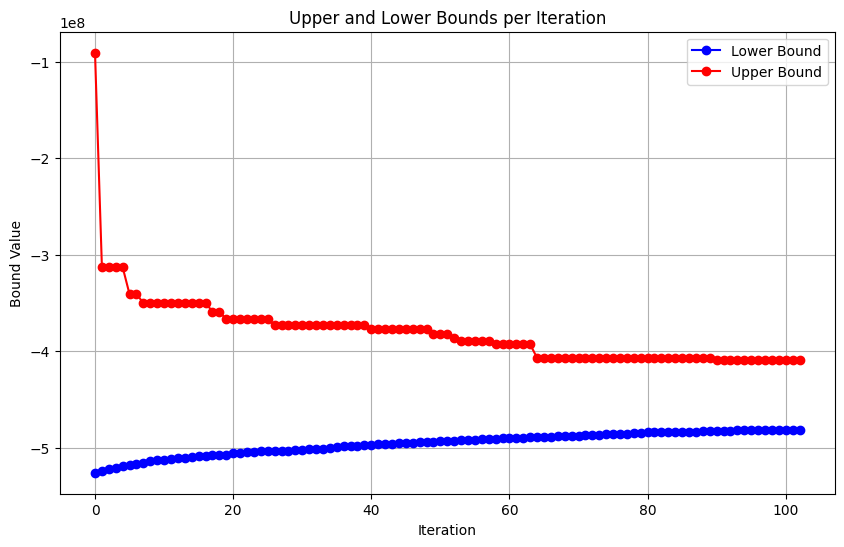

In [11]:
import matplotlib.pyplot as plt

# # Adjust the length of both lists to match the shorter one
# min_length = min(len(lower_bounds), len(upper_bounds))

# # Trim both lists to the same length
# lower_bounds = lower_bounds[:min_length]
# upper_bounds = upper_bounds[:min_length]
# iterations = list(range(min_length))

# Plot the adjusted lower and upper bounds
plt.figure(figsize=(10, 6))
plt.plot(LB, label="Lower Bound", marker="o", linestyle="-", color="blue")
plt.plot(UB, label="Upper Bound", marker="o", linestyle="-", color="red")

# Labels and title
plt.xlabel("Iteration")
plt.ylabel("Bound Value")
plt.title("Max Profit Bound Convergence")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()
